# Tarea 2 FIS2421: pipeline paso a paso

Este notebook ejecuta el pipeline de `instrastro` **una noche a la vez**, mostrando los resultados de cada paso en el orden de la tarea (puntos 11 a 16) y de las secciones del informe. Para procesar todas las noches de una sola vez y obtener la tabla comparativa, usa `python run_pipeline.py config.yaml`.

**Antes de empezar**
1. Copia `config.example.yaml` como `config.yaml` y ajusta las rutas a tus FITS, el objeto y las estrellas estándar.
2. ¿Todavía no tienes datos? Ejecuta `python run_pipeline.py --demo demo` y usa `demo/config.yaml`: son datos sintéticos con valores verdaderos conocidos.

Todos los resultados (FITS, tablas `.ecsv` y `.tex`, figuras `.png`) quedan en `<salida>/<noche>/`.

In [2]:
import json, logging, os, sys
from pathlib import Path
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))   # carpeta pipeline/
from instrastro import pipeline
from instrastro.io import load_config
from astropy.table import Table

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

CONFIG = os.environ.get("INSTRASTRO_CONFIG", "../config.yaml")   # <- tu archivo
NOCHE = 0                                                         # índice de la noche a procesar

cfg = load_config(CONFIG)
ctx = pipeline.Context(cfg, cfg["noches"][NOCHE])
print("Noche:", ctx.name, "| resultados en", ctx.out)

Noche: calib2025 | resultados en C:\Users\marti\Test-Instr-Astro\pipeline\resultados\calib2025


## Observaciones: bitácora y visibilidad

Tabla con todos los archivos de la noche (tipo, filtro, hora UTC, tiempo de exposición, masa de aire) y curvas de altura del objeto y de las estándares, con la Luna. Las tablas `.tex` se pueden pegar directamente en el informe.

In [ ]:
pipeline.paso_bitacora(ctx)
display(Table.read(ctx.out / "bitacora.ecsv"))
if (ctx.figs / "visibilidad.png").exists():
    display(Image(ctx.figs / "visibilidad.png"))

## 11. Reducción

$$I_\mathrm{red} = \frac{I_\mathrm{cruda} - \mathrm{Bias} - \mathrm{DC}\cdot t}{\mathrm{Flat}_\mathrm{norm}\cdot t}\quad[\mathrm{ADU/s}]$$

- **Master bias**: mediana de los bias. El ruido de lectura se estima con la diferencia de dos bias.
- **Dark current (DC)**: promedio de (dark − bias)/t_dark, en ADU/s. Así se puede escalar a cualquier tiempo de exposición.
- **Master flat**: cada flat se corrige por bias + DC·t y se normaliza por **su propia** mediana antes de combinar (los flats de crepúsculo cambian de nivel). Las esquinas viñeteadas y los píxeles de la BPM quedan en NaN (no en 0).
- **Ciencia**: cada exposición se reduce, se alinea a la primera de V por correlación cruzada y se combina con promedio sigma-clipped (elimina rayos cósmicos y satélites). B se alinea al apilado de V, así los dos filtros quedan en la misma grilla de píxeles.

INFO [calib2025] master bias (10) y dark current (10)
INFO [calib2025] master flat B (10)
INFO [calib2025] master flat V (10)


{
 "n_bias": 10,
 "n_darks": 10,
 "bias_mediana_adu": 92.5,
 "ruido_lectura_adu": 4.193432330030122,
 "ruido_lectura_e": 3.5644174805256035,
 "dark_current_mediana_adu_s": -0.039000000804662704,
 "flats": {
  "B": {
   "n": 10,
   "niveles_adu": [
    37958.1875,
    36016.90234375,
    34136.69921875,
    32372.271484375,
    30566.51171875,
    28822.419921875,
    27142.12109375,
    25513.98828125,
    23911.677734375,
    22345.23046875
   ]
  },
  "V": {
   "n": 10,
   "niveles_adu": [
    37009.46484375,
    33678.69921875,
    30707.845703125,
    27716.150390625,
    25099.994140625,
    22728.47265625,
    20465.5078125,
    34906.08203125,
    30153.40625,
    26029.521484375
   ]
  }
 }
}


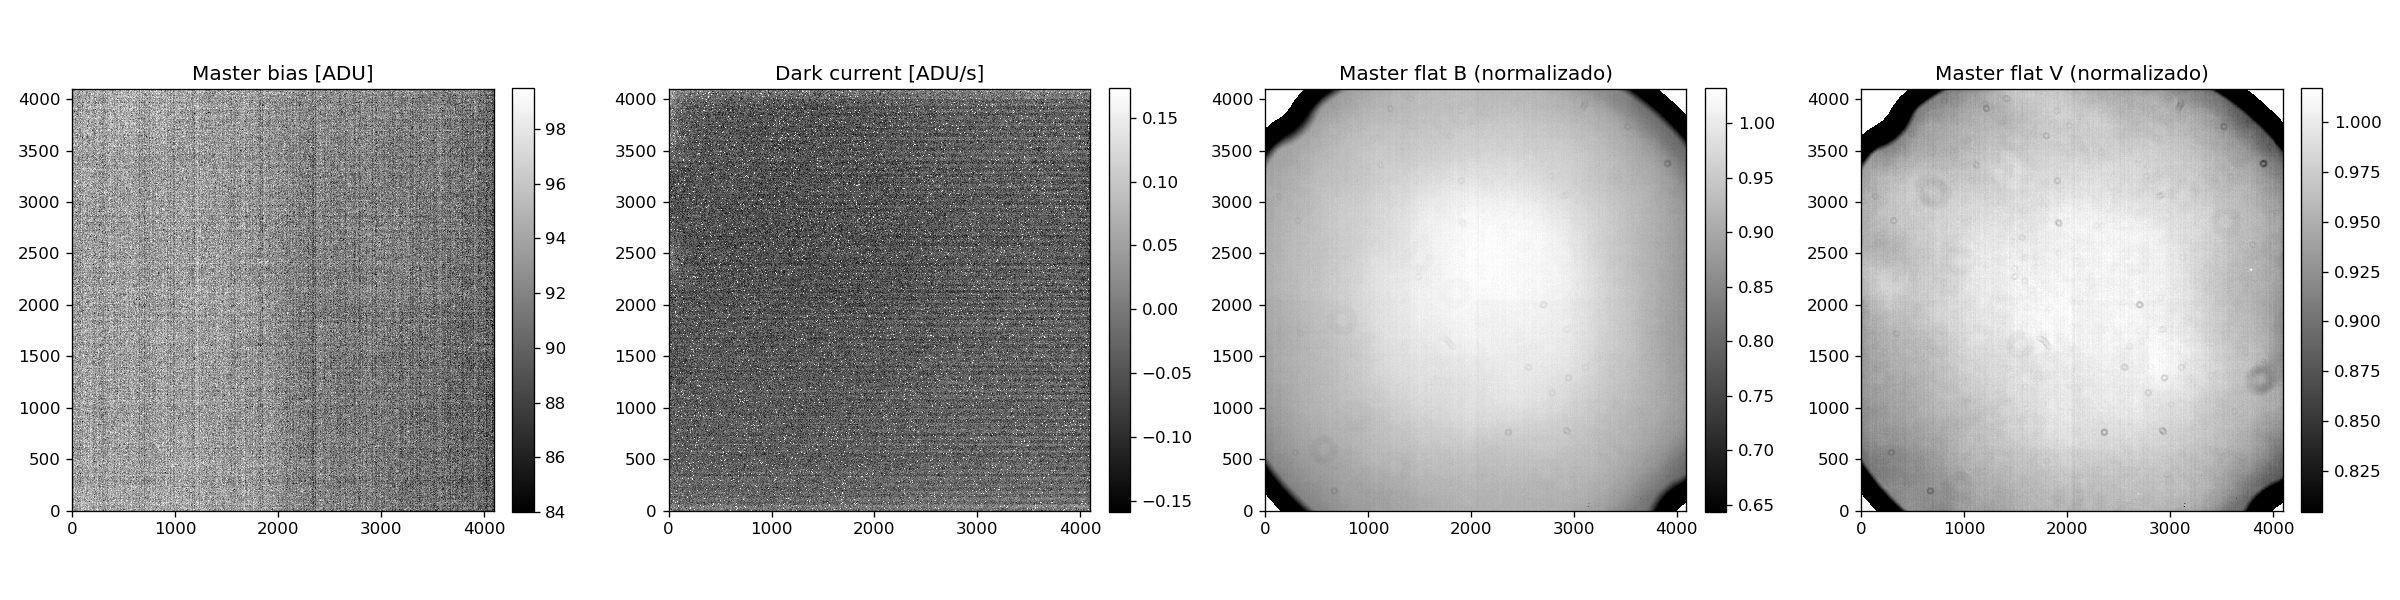

In [3]:
calib = pipeline.paso_calibracion(ctx)
print(json.dumps(json.loads((ctx.out / "calibracion.json").read_text()), indent=1, ensure_ascii=False))
display(Image(ctx.figs / "calibracion.png"))

In [ ]:
stacks = pipeline.paso_ciencia(ctx, calib)
for filt in stacks:
    display(Image(ctx.figs / f"reduccion_{filt}.png"))
# Desplazamientos, fondo y seeing de cada exposición individual
display(Table.read(ctx.out / "exposiciones.ecsv"))

## 12. Calibración astrométrica

Según `astrometria.modo` en el YAML. Con `header` se obtiene un WCS aproximado. Para el informe conviene resolver con astrometry.net: sube `stack_V.fits` a https://nova.astrometry.net, descarga el `wcs.fits` y usa el modo `archivo`, o bien automatízalo con el modo `astrometry_net`. Se reportan la escala de placa, la rotación y la matriz CD.

In [ ]:
wcs = pipeline.paso_astrometria(ctx, stacks)
print(json.dumps(json.loads((ctx.out / "astrometria.json").read_text()), indent=1))

## 13. Calibración fotométrica

$$m_\mathrm{std} = -2.5\log_{10} F + ZP - kX$$

- F se mide con fotometría de apertura (radio 3 FWHM, fondo en un anillo) en **cada** exposición de las estándares, así el ZP sale con su dispersión y su error.
- Las magnitudes Tycho (BT, VT) se convierten a Johnson B, V.
- k son coeficientes de extinción típicos de Cerro Tololo (configurables) y X es la masa de aire.
- Se excluyen las mediciones de estrellas saturadas.
- Si la noche no tiene estándares, se usa el ZP promedio de las otras noches.

In [4]:
std_tbl, zp_tbl = pipeline.paso_estandares(ctx, calib)
zps = pipeline._zp_dict(zp_tbl)
if std_tbl is not None:
    display(std_tbl)
    display(zp_tbl)
else:
    print("Esta noche no tiene estándares: define zps a mano o corre run_pipeline.py con todas las noches")

estrella,filtro,archivo,airmass,flujo_adu_s,fwhm_arcsec,r_apertura_px,saturada,m_std,zp
str10,str1,str29,float64,float64,float64,float64,bool,float64,float64
HIP 116375,B,V462_B_5.000secs_00000557.fit,1.15560012708022,258694.14656247568,1.990565783058766,18.838161984783273,False,8.15012,21.97098653703284
HIP 116375,B,V462_B_5.000secs_00000558.fit,1.15531832293019,263749.23002517724,2.563598760009291,24.2611870032425,False,8.15012,21.9919275818637
HIP 116375,B,V462_B_5.000secs_00000559.fit,1.15507531270916,261810.88570235932,2.470324113377101,23.37846164079275,False,8.15012,21.983858077929007
HIP 116375,B,V462_B_5.000secs_00000560.fit,1.15483407275927,263213.7360616641,2.499659365225667,23.656082320747636,False,8.15012,21.98959989220992
HIP 116375,B,V462_B_5.000secs_00000561.fit,1.15459288264052,262125.50904757198,2.349896205307676,22.238765349914914,False,8.15012,21.985041437844696
HIP 116375,B,V462_B_5.000secs_00000562.fit,1.15435106751986,264100.7698623421,2.440025918238001,23.091727932851743,False,8.15012,21.99313193485827
HIP 116375,B,V462_B_5.000secs_00000563.fit,1.15411394131131,265007.9722442217,3.1462621283381664,29.77535137228549,False,8.15012,21.996795832901874
HIP 116375,B,V462_B_5.000secs_00000564.fit,1.15387619798166,263379.2683694131,2.3436055232463975,22.17923208119619,False,8.15012,21.990043016804787
HIP 116375,B,V462_B_5.000secs_00000565.fit,1.1536352898314,264540.16130702535,2.8267281611979014,26.751370610705692,False,8.15012,21.994757857525645


filtro,zp,zp_std,zp_err,n
str1,float64,float64,float64,int32
B,21.8449954454314,0.14382789478305158,0.03216089497955907,20
V,21.94104732233017,0.007756165158431101,0.0017343312538967367,20


## 15. Seeing y PSF

Se ajusta una gaussiana 2D elíptica a las estrellas aisladas y no saturadas de **cada exposición** y del apilado. Se reporta:
- la mediana del FWHM y su dispersión;
- la comparación con el límite de difracción (1.22 λ/D ≈ 0.28″ en V para 0.5 m);
- la FWHM en una grilla de 3x3 sobre el detector y la pendiente del FWHM con la distancia al centro, para ver si la PSF varía en el campo.

In [ ]:
seeing_res, psfs = pipeline.paso_seeing(ctx, stacks)
for filt, s in seeing_res.items():
    print(f"{filt}: seeing apilado {s['seeing_apilado_arcsec']:.2f}\" "
          f"(exposiciones: {s['seeing_exposiciones_mediana']:.2f}\"), "
          f"{s['razon_seeing_difraccion']:.1f} veces el límite de difracción, "
          f"pendiente radial {s['pendiente_radial_arcsec_por_1000px']:+.3f} ± {s['pendiente_radial_err']:.3f} \"/1000 px")
display(Image(ctx.figs / "seeing.png"))

## 14. Detección de objetos y catálogos

Dos configuraciones (parámetros en `detection.DEFAULT_CONFIGS`, modificables en el YAML):

| | agresiva | extendida |
|---|---|---|
| objetivo | separar estrellas del cúmulo | detectar la emisión difusa |
| fondo | caja de 64 px + quita la nebulosa (> 4 FWHM) | caja de 512 px: la nebulosa **no** se resta |
| filtro | 1 × seeing | 3 × seeing |
| umbral / área mínima | 3σ / 10 px | 1.5σ / 400 px |
| deblending | 64 niveles, contraste 0.0005 | 16 niveles, contraste 0.2 |
| flujo | apertura de 1 FWHM + corrección de apertura | flujo total del segmento |

Con el catálogo agresivo en B y V, cruzado por posición, se construye el diagrama color-magnitud V vs B−V.

In [ ]:
catalogs, cat_res = pipeline.paso_catalogos(ctx, stacks, wcs, zps, psfs)
for key, info in cat_res.items():
    if isinstance(info, dict):
        print(key, {k: v for k, v in info.items() if k != "parametros"})
display(Image(ctx.figs / "segmentacion.png"))
if (ctx.figs / "color_magnitud.png").exists():
    display(Image(ctx.figs / "color_magnitud.png"))

## 16. Imagen en color

R = V, G = (B+V)/2, B = B, con el estiramiento asinh de Lupton. También se genera un mapa de color superficial B−V calibrado.

In [ ]:
pipeline.paso_color(ctx, stacks, zps)
display(Image(ctx.figs / "color_rgb.png"))
if (ctx.figs / "mapa_color_BV.png").exists():
    display(Image(ctx.figs / "mapa_color_BV.png"))

## Resumen de la noche (para comparar noches)

Brillo del cielo en mag/arcsec², magnitud límite a 5σ, seeing, masa de aire, iluminación y distancia de la Luna. Repite el notebook con `NOCHE = 1`, o corre `run_pipeline.py`, que junta todas las noches en `comparacion_noches.tex`.

In [ ]:
pipeline.paso_resumen_noche(ctx, stacks, zps, seeing_res)